# Análise de Dados - Salários em Data Science 

**Dataset**: [Link](./data/data_science_salaries.csv)  
**Período de Análise**: (2020 - 2024)

## **Explorando os dados**

### Importando Bibliotecas & Helpers


In [1]:
from utils.helpers import (
    generate_unique_values_table,
    get_dimensions,
    COLUNAS_ORDENADAS,
)
from IPython.display import display, Markdown

import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    mean_squared_error,
    r2_score,
    roc_curve,
    roc_auc_score,
)
from scipy import stats

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import requests

sns.set_style(style="whitegrid")


currency = "USD"  # ou "BRL"

currency_graph_formatter = (
    ticker.FuncFormatter(lambda x, pos: f"${x:,.0f}")
    if currency == "USD"
    else ticker.FuncFormatter(lambda x, pos: f"R${x:,.0f}")
)

if currency == "BRL":
    url = "https://economia.awesomeapi.com.br/json/last/" + "USD-BRL"
    response = requests.get(url)
    data = response.json()
    taxa_usd_brl = float(data["USDBRL"]["bid"])
    print(f"Taxa de câmbio USD/BRL: {taxa_usd_brl}")


def set_styled_caption(styler, caption_text, align_first_col=True):
    """
    Aplica uma legenda estilizada e alinha a primeira coluna do corpo da tabela à esquerda.
    """
    caption_style = [
        {
            "selector": "caption",
            "props": [
                ("padding-bottom", "8px"),
            ],
        }
    ]
    first_col_align_style = [
        {
            "selector": "tbody tr > *:nth-child(1)",
            "props": [
                ("text-align", "left"),
            ],
        },
        {
            "selector": "thead tr > *:nth-child(1)",
            "props": [
                ("text-align", "left"),
            ],
        },
    ]
    styler = styler.set_caption(f"<strong>{caption_text}</strong>")
    all_styles = (
        caption_style + first_col_align_style if align_first_col else caption_style
    )

    return styler.set_table_styles(all_styles)


### Carregando o dataset


In [2]:
df_salary = pd.read_csv("./data/data_science_salaries.csv", sep=",")

In [3]:
periodo = f"{df_salary['work_year'].min()} - {df_salary['work_year'].max()}"

markdown_text = f"""
**Dimensões:** {get_dimensions(df_salary)}  
**Período:** {periodo}  
"""

display(Markdown(markdown_text))

display(df_salary.head())


**Dimensões:** 6.599 registros, 11 colunas  
**Período:** 2020 - 2024  


,job_title,experience_level,employment_type,work_models,work_year,employee_residence,salary,salary_currency,salary_in_usd,company_location,company_size
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium


### Formatando os dados


In [4]:
df_salary_formatted = df_salary.copy()

df_salary_formatted["work_year"] = df_salary_formatted["work_year"].astype("uint16")
df_salary_formatted["salary"] = df_salary_formatted["salary_in_usd"].astype("uint32")

df_salary_formatted["remote_ratio"] = df_salary_formatted["work_models"].map(
    {"On-site": 0, "Hybrid": 50, "Remote": 100}
)
df_salary_formatted["remote_ratio"] = df_salary_formatted["remote_ratio"].astype(
    "uint8"
)

if currency == "BRL":
    df_salary_formatted["salary"] = round(
        (df_salary_formatted["salary"] * taxa_usd_brl) / 12, 2
    )

df_salary_formatted = df_salary_formatted[COLUNAS_ORDENADAS]

numerical_cols = df_salary_formatted.select_dtypes(
    include=["int16", "int8", "int64", "float64", "uint8", "uint16", "uint32"]
).columns
categorical_cols = df_salary_formatted.select_dtypes(
    include=["category", "bool", "boolean", "object"]
).columns

for col in categorical_cols:
    df_salary_formatted[col] = df_salary_formatted[col].astype("category")

df_salary_formatted.info(memory_usage="deep")

old_memory = df_salary.memory_usage(deep=True).sum()
new_memory = df_salary_formatted.memory_usage(deep=True).sum()
reducao = (old_memory - new_memory) / old_memory * 100

memory_md = f"""
**Memória antes do processamento:** {old_memory / 1024:.2f} KB  
**Memória após o processamento:** {new_memory / 1024:.2f} KB  
**Redução:** {reducao:.2f}%  
"""

display(Markdown(memory_md))

df_salary_formatted.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6599 entries, 0 to 6598
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   job_title           6599 non-null   category
 1   experience_level    6599 non-null   category
 2   employment_type     6599 non-null   category
 3   company_location    6599 non-null   category
 4   company_size        6599 non-null   category
 5   employee_residence  6599 non-null   category
 6   work_models         6599 non-null   category
 7   remote_ratio        6599 non-null   uint8   
 8   work_year           6599 non-null   uint16  
 9   salary              6599 non-null   uint32  
dtypes: category(7), uint16(1), uint32(1), uint8(1)
memory usage: 124.4 KB



**Memória antes do processamento:** 3174.78 KB  
**Memória após o processamento:** 124.41 KB  
**Redução:** 96.08%  


,job_title,experience_level,employment_type,company_location,company_size,employee_residence,work_models,remote_ratio,work_year,salary
0,Data Engineer,Mid-level,Full-time,United States,Medium,United States,Remote,100,2024,148100
1,Data Engineer,Mid-level,Full-time,United States,Medium,United States,Remote,100,2024,98700
2,Data Scientist,Senior-level,Full-time,United States,Medium,United States,Remote,100,2024,140032
3,Data Scientist,Senior-level,Full-time,United States,Medium,United States,Remote,100,2024,100022
4,BI Developer,Mid-level,Full-time,United States,Medium,United States,On-site,0,2024,120000


### Valores únicos por categoria


In [5]:
display(Markdown(generate_unique_values_table(df_salary_formatted, 200, show_count=True)))

| Coluna                     | Contagem | Valores |
|----------------------------|----------|---------|
| job_title                    |   132    | AI Architect, AI Developer, AI Engineer, AI Product Manager, AI Programmer, AI Research Engineer, AI Scientist, AWS Data Architect, Analytics Engineer, Analytics Engineering Manager, Applied Data Scientist, Applied Machine Learning Engineer, Applied Machine Learning Scientist, Applied Scientist, Autonomous Vehicle Technician, Azure Data Engineer, BI Analyst, BI Data Analyst, BI Data Engineer, BI Developer, Big Data Architect, Big Data Engineer, Business Data Analyst, Business Intelligence Analyst, Business Intelligence Data Analyst, Business Intelligence Developer, Business Intelligence Engineer, Business Intelligence Manager, Business Intelligence Specialist, Cloud Data Architect, Cloud Data Engineer, Cloud Database Engineer, Compliance Data Analyst, Computer Vision Engineer, Computer Vision Software Engineer, Consultant Data Engineer, Data Analyst, Data Analyst Lead, Data Analytics Consultant, Data Analytics Engineer, Data Analytics Lead, Data Analytics Manager, Data Analytics Specialist, Data Architect, Data DevOps Engineer, Data Developer, Data Engineer, Data Infrastructure Engineer, Data Integration Engineer, Data Integration Specialist, Data Lead, Data Management Analyst, Data Management Specialist, Data Manager, Data Modeler, Data Modeller, Data Operations Analyst, Data Operations Engineer, Data Operations Manager, Data Operations Specialist, Data Product Manager, Data Product Owner, Data Quality Analyst, Data Quality Engineer, Data Quality Manager, Data Science, Data Science Consultant, Data Science Director, Data Science Engineer, Data Science Lead, Data Science Manager, Data Science Practitioner, Data Science Tech Lead, Data Scientist, Data Scientist Lead, Data Specialist, Data Strategist, Data Strategy Manager, Data Visualization Analyst, Data Visualization Engineer, Data Visualization Specialist, Decision Scientist, Deep Learning Engineer, Deep Learning Researcher, Director of Data Science, ETL Developer, ETL Engineer, Finance Data Analyst, Financial Data Analyst, Head of Data, Head of Data Science, Head of Machine Learning, Insight Analyst, Lead Data Analyst, Lead Data Engineer, Lead Data Scientist, Lead Machine Learning Engineer, ML Engineer, MLOps Engineer, Machine Learning Developer, Machine Learning Engineer, Machine Learning Infrastructure Engineer, Machine Learning Manager, Machine Learning Modeler, Machine Learning Operations Engineer, Machine Learning Research Engineer, Machine Learning Researcher, Machine Learning Scientist, Machine Learning Software Engineer, Machine Learning Specialist, Manager Data Management, Managing Director Data Science, Marketing Data Analyst, Marketing Data Engineer, Marketing Data Scientist, NLP Engineer, Power BI Developer, Principal Data Analyst, Principal Data Architect, Principal Data Engineer, Principal Data Scientist, Principal Machine Learning Engineer, Product Data Analyst, Prompt Engineer, Research Analyst, Research Engineer, Research Scientist, Sales Data Analyst, Software Data Engineer, Staff Data Analyst, Staff Data Scientist, Staff Machine Learning Engineer |
| experience_level             |    4     | Entry-level, Executive-level, Mid-level, Senior-level |
| employment_type              |    4     | Contract, Freelance, Full-time, Part-time |
| company_location             |    75    | Algeria, Andorra, Argentina, Armenia, Australia, Austria, Bahamas, Belgium, Bosnia and Herzegovina, Brazil, Canada, Central African Republic, Chile, China, Colombia, Croatia, Czech Republic, Denmark, Ecuador, Egypt, Estonia, Finland, France, Germany, Ghana, Gibraltar, Greece, Honduras, Hong Kong, Hungary, India, Indonesia, Iran, Iraq, Ireland, Israel, Italy, Japan, Kenya, Latvia, Lebanon, Lithuania, Luxembourg, Malaysia, Malta, Mauritius, Mexico, Moldova, Netherlands, New Zealand, Nigeria, Norway, Pakistan, Philippines, Poland, Portugal, Puerto Rico, Qatar, Romania, Russia, Saudi Arabia, Singapore, Slovenia, South Africa, South Korea, Spain, Sweden, Switzerland, Thailand, Turkey, Ukraine, United Arab Emirates, United Kingdom, United States, Vietnam |
| company_size                 |    3     | Large, Medium, Small |
| employee_residence           |    87    | Algeria, American Samoa, Andorra, Argentina, Armenia, Australia, Austria, Belgium, Bolivia, Bosnia and Herzegovina, Brazil, Bulgaria, Canada, Central African Republic, Chile, China, Colombia, Costa Rica, Croatia, Cyprus, Czech Republic, Denmark, Dominican Republic, Ecuador, Egypt, Estonia, Finland, France, Georgia, Germany, Ghana, Greece, Honduras, Hong Kong, Hungary, India, Indonesia, Iran, Iraq, Ireland, Israel, Italy, Japan, Jersey, Kenya, Kuwait, Latvia, Lebanon, Lithuania, Luxembourg, Malaysia, Malta, Mauritius, Mexico, Moldova, Netherlands, New Zealand, Nigeria, Norway, Pakistan, Peru, Philippines, Poland, Portugal, Puerto Rico, Qatar, Romania, Russia, Saudi Arabia, Serbia, Singapore, Slovenia, South Africa, South Korea, Spain, Sweden, Switzerland, Thailand, Tunisia, Turkey, Uganda, Ukraine, United Arab Emirates, United Kingdom, United States, Uzbekistan, Vietnam |
| work_models                  |    3     | Hybrid, On-site, Remote |


### Colunas Numéricas vs Categóricas


In [6]:
variable_type_summary = (
    """
| Tipo de Variável | Colunas |
|------------------|---------|
"""
    + f"| Numéricas        | {', '.join(numerical_cols)} |\n"
    f"| Categóricas      | {', '.join(categorical_cols)} |\n"
)

display(Markdown(variable_type_summary))


| Tipo de Variável | Colunas |
|------------------|---------|
| Numéricas        | remote_ratio, work_year, salary |
| Categóricas      | job_title, experience_level, employment_type, company_location, company_size, employee_residence, work_models |


## **Parte 1 – Análise Descritiva e Exploratória (EDA)**

**Objetivo:** Identificar o comportamento geral dos salários e fatores relacionados ao perfil profissional.


### **Métricas Obrigatórias**

#### Média, mediana e desvio-padrão de salary.  

In [7]:
salary_stats_geral = df_salary_formatted["salary"].agg(["mean", "median", "std"])

translation_map = {
    "mean": "Média",
    "median": "Mediana",
    "std": "Desvio Padrão",
}

salary_stats_geral.index = salary_stats_geral.index.map(translation_map)

display(
    set_styled_caption(
        salary_stats_geral.to_frame("Geral")
        .reset_index()
        .rename(columns={"index": "Métrica"})
        .style.format({"Geral": "${:,.2f}"})
        .set_properties(subset=["Métrica"], **{"text-align": "left"})
        .hide(axis="index"),
        "Estatísticas Gerais de Salário (USD)",
    )
)

Métrica,Geral
Média,"$145,560.56"
Mediana,"$138,666.00"
Desvio Padrão,"$70,946.84"


#### Distribuição percentual de experience_level, employment_type e company_size.

In [8]:
dist_experience_level = (
    df_salary_formatted["experience_level"].value_counts(normalize=True) * 100
).round(2)
dist_employment_type = (
    df_salary_formatted["employment_type"].value_counts(normalize=True) * 100
).round(2)
dist_company_size = (
    df_salary_formatted["company_size"].value_counts(normalize=True) * 100
).round(2)
dist_work_year = (
    df_salary_formatted["work_year"].value_counts(normalize=True) * 100
).round(2)
dist_country = ((
    df_salary_formatted["company_location"].value_counts(normalize=True) * 100
).round(2)).head(10)


def show_percentual_distribution(series, label):
    styled = (
        series.rename_axis(label)
        .to_frame("Proporção (%)")
        .reset_index()
        .style.format({"Proporção (%)": "{:.2f}%"})
        .set_properties(subset=[label], **{"text-align": "left"})
        .hide(axis="index")
    )
    display(set_styled_caption(styled, f"Distribuição por {label}:"))


show_percentual_distribution(dist_experience_level, "Nível de Experiência")
show_percentual_distribution(dist_employment_type, "Tipo de Contrato")
show_percentual_distribution(dist_company_size, "Porte da Empresa")
show_percentual_distribution(dist_work_year, "Ano de Trabalho")
show_percentual_distribution(dist_country, "País (Top 10)")

Nível de Experiência,Proporção (%)
Senior-level,62.21%
Mid-level,25.38%
Entry-level,8.56%
Executive-level,3.85%


Tipo de Contrato,Proporção (%)
Full-time,99.29%
Contract,0.29%
Part-time,0.24%
Freelance,0.18%


Porte da Empresa,Proporção (%)
Medium,88.80%
Large,8.62%
Small,2.58%


Ano de Trabalho,Proporção (%)
2023,70.09%
2022,16.85%
2024,8.65%
2021,3.27%
2020,1.14%


País (Top 10),Proporção (%)
United States,81.13%
United Kingdom,6.18%
Canada,3.68%
Germany,1.18%
Spain,0.95%
India,0.88%
France,0.74%
Australia,0.48%
Portugal,0.39%
Netherlands,0.32%


#### Top 5 cargos (job_title) com maior média salarial.

In [9]:
top5_job_titles = (
    df_salary_formatted.groupby("job_title", observed=True)["salary"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

display(
    set_styled_caption(
        top5_job_titles.reset_index()
        .rename(columns={"salary": "Média Salarial (USD)", "job_title": "Cargo"})
        .style.format({"Média Salarial (USD)": "${:,.2f}"})
        .set_properties(subset=["Cargo"], **{"text-align": "left"})
        .set_table_styles(
            [
                {
                    "selector": "th.col_heading.level0.col0",
                    "props": [("text-align", "left")],
                }
            ],
            overwrite=False,
        )
        .hide(axis="index"),
        "Top 5 cargos com maior média salarial:",
    )
)

Cargo,Média Salarial (USD)
Analytics Engineering Manager,"$399,880.00"
Data Science Tech Lead,"$375,000.00"
Managing Director Data Science,"$280,000.00"
AWS Data Architect,"$258,000.00"
Cloud Data Architect,"$250,000.00"


#### Correlação entre remote_ratio, company_size e salary.

,remote_ratio,company_size_num,salary
remote_ratio,1.000,0.039,-0.088
company_size_num,0.039,1.000,-0.028
salary,-0.088,-0.028,1.000


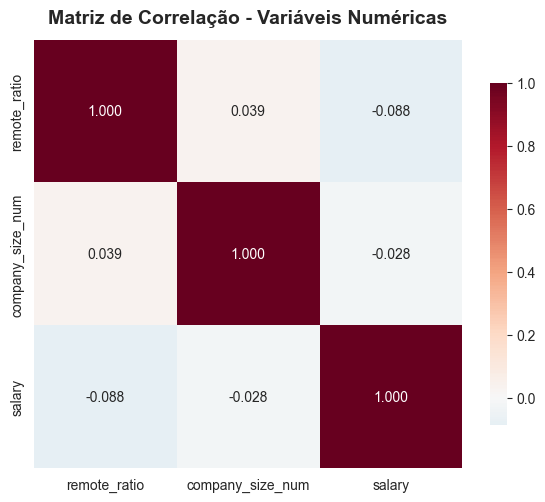

In [10]:
corr_cols = ["remote_ratio", "company_size", "salary"]

company_size_map = {"Small": 0, "Medium": 1, "Large": 2}
df_corr = df_salary_formatted.copy()
df_corr["company_size_num"] = df_corr["company_size"].map(company_size_map)

corr_matrix = df_corr[["remote_ratio", "company_size_num", "salary"]].corr()

display(
    set_styled_caption(
        corr_matrix.style.format("{:.3f}").background_gradient(
            cmap="RdBu_r", axis=None
        ),
        "Matriz de correlação entre remote_ratio, company_size e salary:",
    )
)


plt.figure(figsize=(6, 5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdBu_r",
    center=0,
    square=True,
    fmt=".3f",
    cbar_kws={"shrink": 0.8},
)
plt.title(
    "Matriz de Correlação - Variáveis Numéricas",
    fontsize=14,
    fontweight="bold",
    pad=12,
)
plt.tight_layout()
plt.savefig("./imgs/correlation_matrix-company_size-remote_ratio-salary.png", dpi=300)
plt.show()

#### Boxplot de salary por experience_level e company_location.

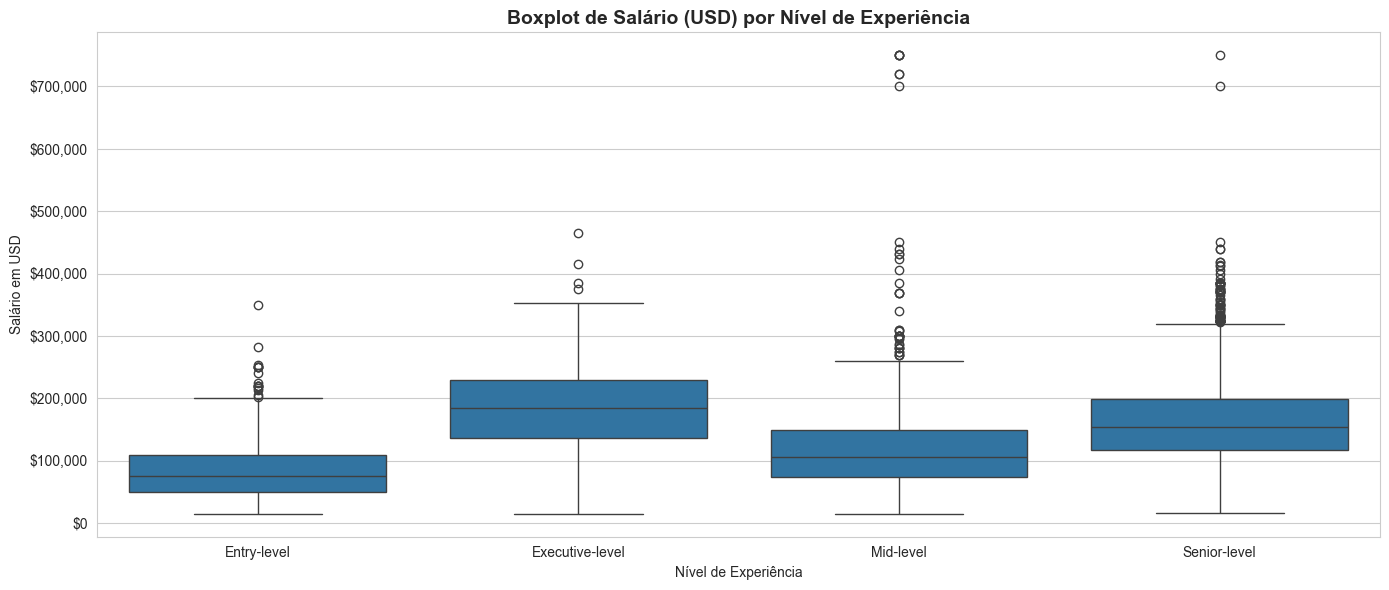

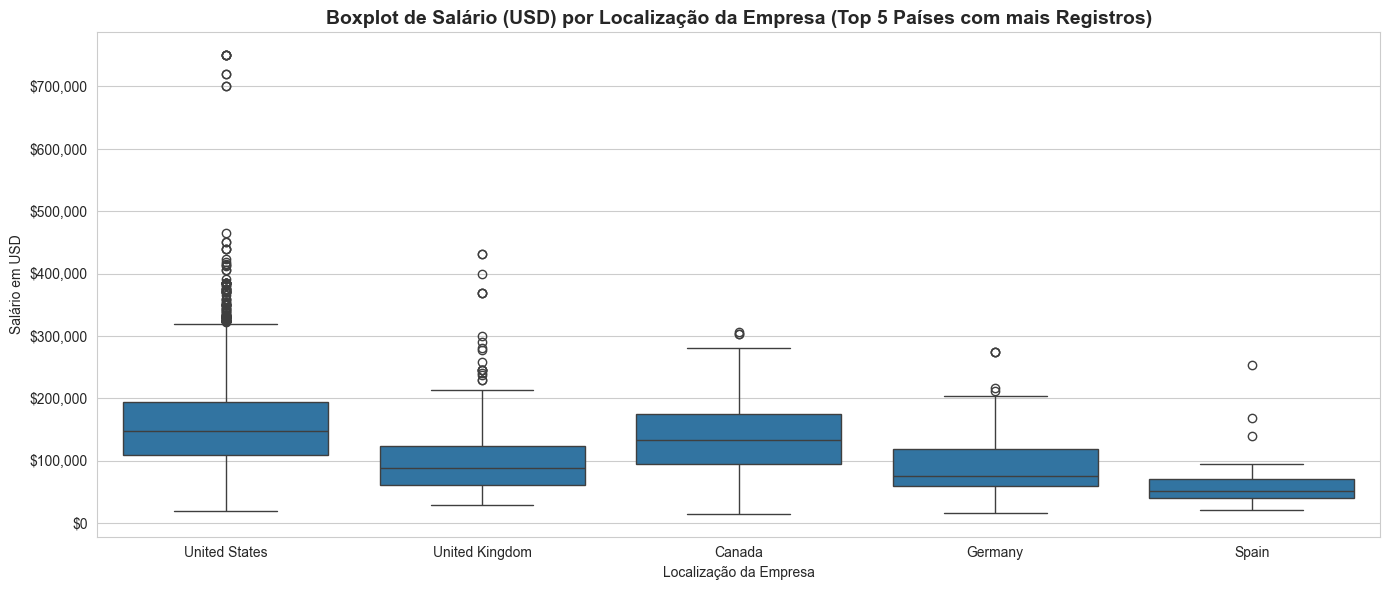

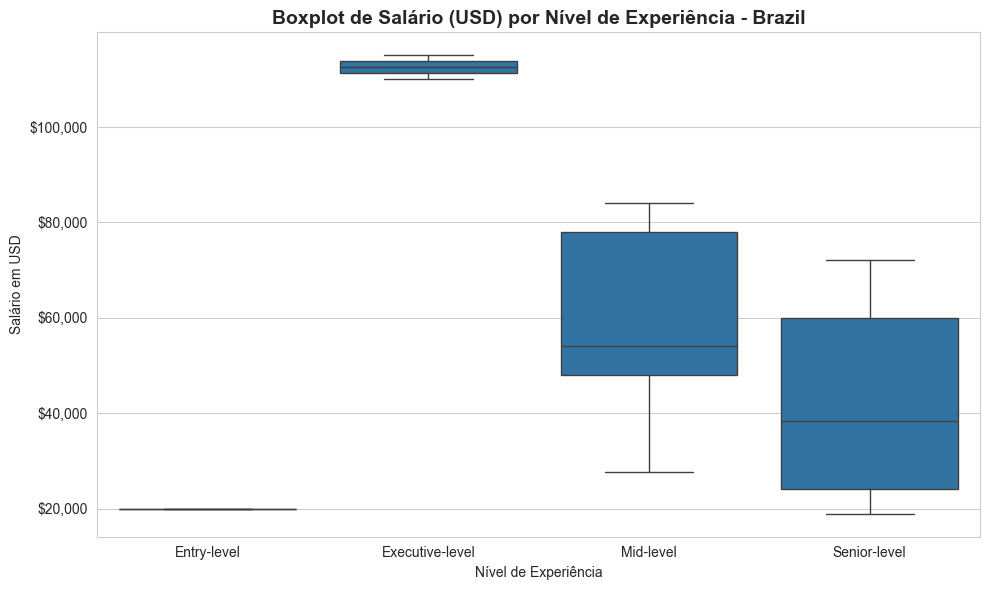

In [11]:
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_salary_formatted,
    x="experience_level",
    y="salary",
)
plt.title(
    "Boxplot de Salário (USD) por Nível de Experiência", fontsize=14, fontweight="bold"
)
plt.xlabel("Nível de Experiência")
plt.ylabel("Salário em USD")

ax = plt.gca()
ax.yaxis.set_major_formatter(currency_graph_formatter)

plt.tight_layout()
plt.savefig("./imgs/boxplot/boxplot-experience_level-salary.png", dpi=300)
plt.show()


top5_locations = df_salary_formatted["company_location"].value_counts().head(5).index

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_salary_formatted[
        df_salary_formatted["company_location"].isin(top5_locations)
    ],
    x="company_location",
    y="salary",
    order=top5_locations,
)
plt.title(
    "Boxplot de Salário (USD) por Localização da Empresa (Top 5 Países com mais Registros)",
    fontsize=14,
    fontweight="bold",
)

plt.xlabel("Localização da Empresa")
plt.ylabel("Salário em USD")
ax = plt.gca()
ax.yaxis.set_major_formatter(currency_graph_formatter)
plt.tight_layout()
plt.savefig("./imgs/boxplot/boxplot-company_location-salary.png", dpi=300)
plt.show()


def plot_boxplot_experience_by_country(df, country):
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=df[df["company_location"] == country],
        x="experience_level",
        y="salary",
    )
    plt.title(
        f"Boxplot de Salário (USD) por Nível de Experiência - {country}",
        fontsize=14,
        fontweight="bold",
    )
    ax = plt.gca()
    formatter = ticker.FuncFormatter(lambda x, pos: f"${x:,.0f}")
    ax.yaxis.set_major_formatter(formatter)
    plt.xlabel("Nível de Experiência")
    plt.ylabel("Salário em USD")
    plt.tight_layout()
    plt.savefig(f"./imgs/boxplot/boxplot-experience_level-salary-{country}.png", dpi=300)
    plt.show()


plot_boxplot_experience_by_country(df_salary_formatted, "Brazil")

### **Perguntas executivas**


#### **Q1**: Qual é a média e o desvio-padrão do $salary\_in\_usd$ para cada categoria de $experience\_level$? Qual nível apresenta maior variabilidade salarial e o que isso indica sobre o mercado?


In [12]:
salary_stats_exp = (
    df_salary_formatted.groupby("experience_level", observed=True)["salary"]
    .agg(["mean", "median", "std", "count"])
    .sort_values("mean", ascending=False)
)

maior_variabilidade = salary_stats_exp["std"].idxmax()
variabilidade_valor = salary_stats_exp.loc[maior_variabilidade, "std"]

dist_percentual = (
    df_salary_formatted["experience_level"].value_counts(normalize=True) * 100
).round(2)

display(
    set_styled_caption(
        salary_stats_exp.reset_index()
        .rename(
            columns={
                "experience_level": "Nível de Experiência",
                "mean": "Média",
                "median": "Mediana",
                "std": "Desvio Padrão",
                "count": "Contagem",
            }
        )
        .style.format(
            {
                "Média": "${:,.2f}",
                "Mediana": "${:,.2f}",
                "Desvio Padrão": "${:,.2f}",
                "Contagem": "{:d}",
            }
        )
        .set_properties(subset=["Nível de Experiência"], **{"text-align": "left"})
        .hide(axis="index"),
        "Estatísticas por nível de experiência:",
    )
)

display(
    Markdown(
        f"**Maior variabilidade salarial:** {maior_variabilidade} (desvio-padrão = {variabilidade_valor:,.2f})"
    )
)

Nível de Experiência,Média,Mediana,Desvio Padrão,Contagem
Executive-level,"$189,687.35","$184,560.00","$71,571.17",254
Senior-level,"$162,071.06","$153,600.00","$64,444.88",4105
Mid-level,"$119,019.81","$106,500.00","$71,783.36",1675
Entry-level,"$84,448.92","$75,000.00","$48,758.32",565


**Maior variabilidade salarial:** Mid-level (desvio-padrão = 71,783.36)

##### **Resposta**: 
O Nível Intermediário (Mid-level) é o que apresenta a maior variabilidade salarial (desvio-padrão de $71.783,36), superando por pouco o Nível Executivo.

Isso indica que o mercado para "Mid-level" é o menos padronizado. O termo abrange uma gama muito ampla de funções e especialidades. Na prática, há uma enorme disparidade entre os salários mais baixos e os mais altos dentro dessa mesma categoria.

#### **Q2**: Qual tipo de contrato ($employment\_type$) apresenta maior média salarial? Essa diferença se mantém entre portes de empresa ($company\_size$)?


In [13]:
mean_salary_by_contract = (
    df_salary_formatted.groupby("employment_type", observed=True)["salary"]
    .mean()
    .sort_values(ascending=False)
)

display(
    set_styled_caption(
        mean_salary_by_contract.reset_index()
        .rename(
            columns={
                "employment_type": "Tipo de Contrato",
                "salary": "Média Salarial (USD)",
            }
        )
        .style.format({"Média Salarial (USD)": "${:,.2f}"})
        .hide(axis="index"),
        "Média salarial por tipo de contrato:",
    )
)

mean_salary_by_contract_and_size = (
    df_salary_formatted.groupby(["employment_type", "company_size"], observed=True)[
        "salary"
    ]
    .mean()
    .unstack("company_size")
    .loc[mean_salary_by_contract.index]
)

display(
    set_styled_caption(
        mean_salary_by_contract_and_size.rename_axis("Tipo de Contrato")
        .rename(columns={"Small": "Pequena", "Medium": "Média", "Large": "Grande"})
        .rename_axis(columns=None)
        .style.format("${:,.2f}"),
        "Média salarial por tipo de contrato e porte da empresa",
    )
)

Tipo de Contrato,Média Salarial (USD)
Full-time,"$146,035.00"
Contract,"$117,109.37"
Part-time,"$55,291.06"
Freelance,"$51,923.17"


,Grande,Média,Pequena
Tipo de Contrato,,,
Full-time,"$121,647.26","$149,842.57","$89,037.35"
Contract,"$113,500.67","$107,395.67","$128,528.57"
Part-time,"$36,944.60","$78,994.33","$45,193.60"
Freelance,"$20,000.00","$71,111.00","$41,253.83"


##### **Resposta**:

O **Full-time** (período integral) é o tipo de contrato com a maior média salarial geral, com **$146.035,00**.

No entanto, essa liderança **não se mantém** em todos os portes de empresa.

* Em empresas **Grandes** e **Médias**, o "Full-time" de fato lidera.
* Em empresas **Pequenas**, o "Contract" (contrato por projeto/temporário) apresenta uma média salarial significativamente maior ($128.528,57) do que o "Full-time" ($89.037,35).

#### **Q3**: Compare a média de $salary\_in\_usd$ por $company\_location$. Quais países se destacam por maiores ou menores salários? Que fatores econômicos podem justificar essa diferença?


Localização da Empresa,Média Salarial (USD),Nº de Registros
Qatar,"$300,000.00",1
Israel,"$217,332.00",3
Puerto Rico,"$167,500.00",4
United States,"$157,073.10",5354
New Zealand,"$151,634.33",3


Localização da Empresa,Média Salarial (USD),Nº de Registros
Thailand,"$22,971.33",3
Turkey,"$22,313.60",5
Honduras,"$20,000.00",1
Moldova,"$18,000.00",1
Ecuador,"$16,000.00",1


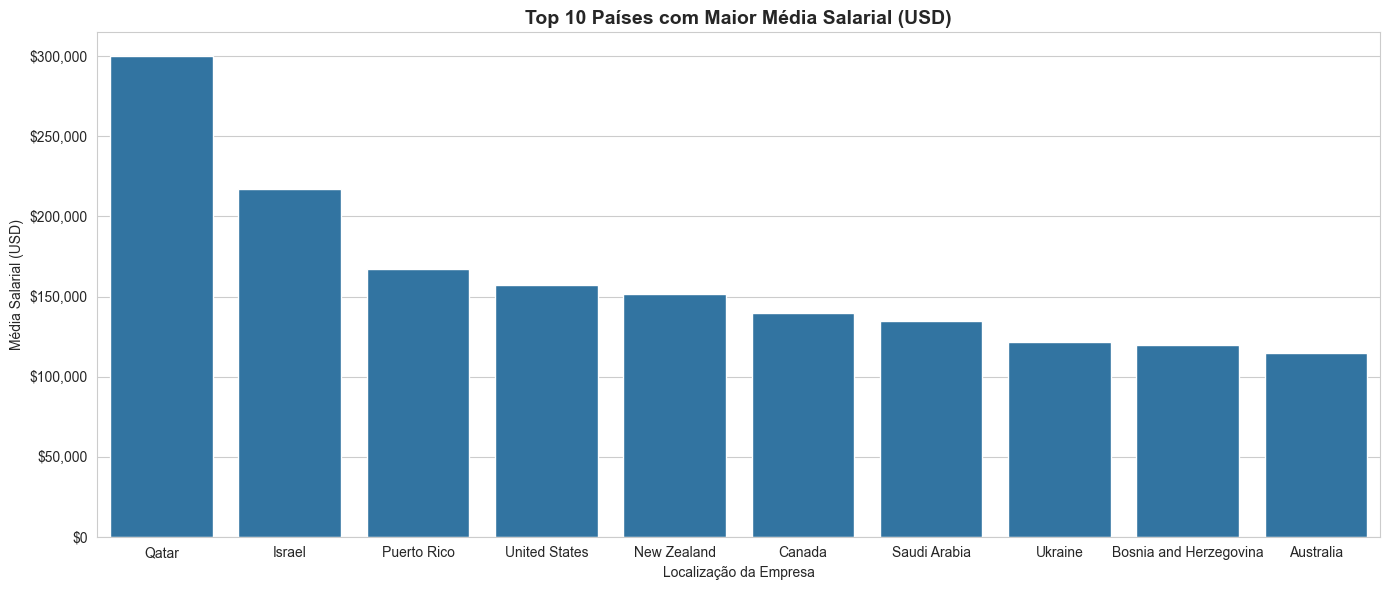

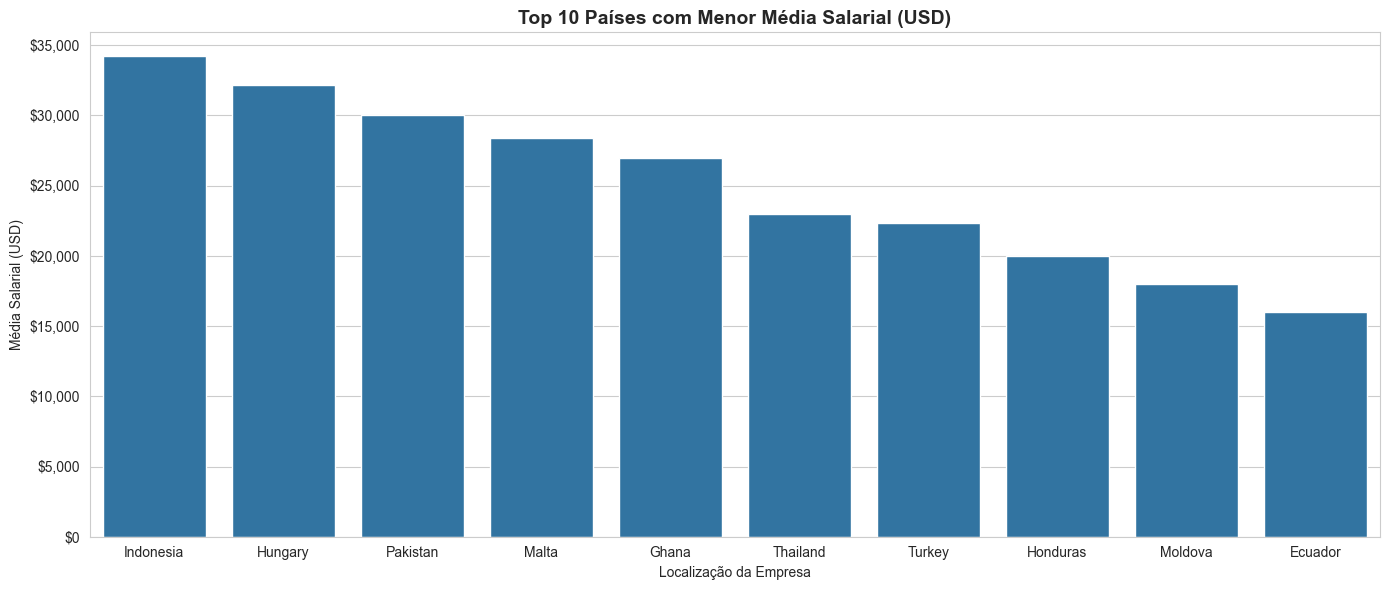

In [14]:
all_sorted_locations = (
    df_salary_formatted.groupby("company_location", observed=True)["salary"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

top_5_locations = all_sorted_locations.head(5)
bottom_5_locations = all_sorted_locations.tail(5)


def style_location_df(df):
    """Aplica a formatação de estilo ao DataFrame de localização."""
    return (
        df.reset_index()
        .rename(
            columns={
                "company_location": "Localização da Empresa",
                "mean": "Média Salarial (USD)",
                "count": "Nº de Registros",
            }
        )
        .style.format({"Média Salarial (USD)": "${:,.2f}", "Nº de Registros": "{:d}"})
        .hide(axis="index")
    )


display(
    set_styled_caption(
        style_location_df(top_5_locations),
        "Top 5 - Média salarial e quantidade de registros por localização:",
    )
)
display(
    set_styled_caption(
        style_location_df(bottom_5_locations),
        "Últimos 5 - Média salarial e quantidade de registros por localização:",
    )
)

plt.figure(figsize=(14, 6))
top_n = 10
sns.barplot(
    data=all_sorted_locations.head(top_n).reset_index(),
    x="company_location",
    y="mean",
    order=all_sorted_locations.head(top_n).index,
)
plt.title(
    f"Top {top_n} Países com Maior Média Salarial (USD)", fontsize=14, fontweight="bold"
)
plt.xlabel("Localização da Empresa")
plt.ylabel("Média Salarial (USD)")
ax = plt.gca()
ax.yaxis.set_major_formatter(currency_graph_formatter)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
bottom_n = 10
sns.barplot(
    data=all_sorted_locations.tail(bottom_n).reset_index(),
    x="company_location",
    y="mean",
    order=all_sorted_locations.tail(bottom_n).index,
)
plt.title(
    f"Top {bottom_n} Países com Menor Média Salarial (USD)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Localização da Empresa")
plt.ylabel("Média Salarial (USD)")
ax = plt.gca()
ax.yaxis.set_major_formatter(currency_graph_formatter)
plt.tight_layout()
plt.show()


##### **Resposta**:

**Maiores Salários**: Qatar ($300.000), Israel ($217.332) e Estados Unidos ($157.073)  
(Ps: Porto Rico também se destaca ($167,500), mas é um território dos EUA).

**Menores Salários**: Equador ($16.000), Moldova ($18.000) e Honduras ($20.000)

**Justificativas Econômicas**: Países com economias mais ricas (alto PIB per capita e alta produtividade), como EUA e Qatar, têm maior capacidade de pagar salários altos. Além disso, a demanda por profissionais de Data Science é maior em países com setores tecnológicos mais desenvolvidos, o que também eleva os salários.

#### **Q4**: Analise a correlação entre $remote\_ratio$ e $salary\_in\_usd$. Há indícios de que o trabalho remoto impacte positivamente ou negativamente o salário? Explique.


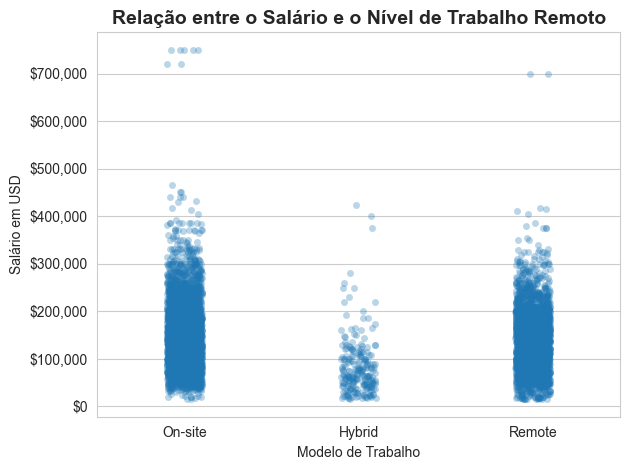

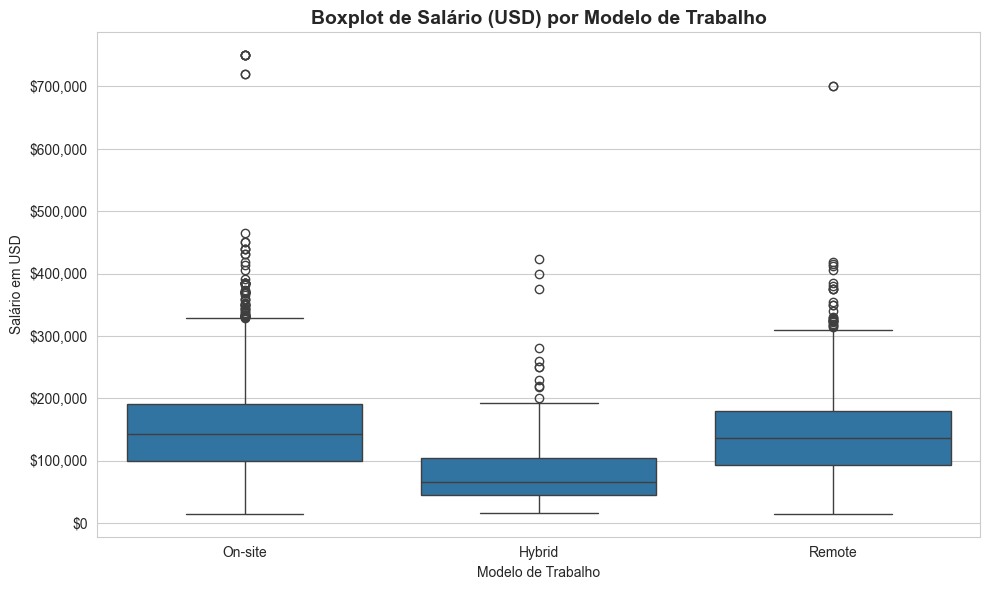

**Correlação entre Nível Remoto e Salário** -0.088 <br>Valores próximos de 0 indicam pouca ou nenhuma relação linear entre o nível de trabalho remoto e o salário.

**Teste de Kruskal-Wallis**  
Estatística H: 261.5888  
Valor-p: 1.5729e-57  
Nível de significância: 0.05  

**Conclusão:** Rejeitamos a hipótese nula.  
Há diferença significativa entre pelo menos dois grupos.

In [15]:
sns.stripplot(
    data=df_salary_formatted,
    x="work_models",
    y="salary",
    alpha=0.3,
    order=["On-site", "Hybrid", "Remote"],
    jitter=0.1,
)
plt.title(
    "Relação entre o Salário e o Nível de Trabalho Remoto",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Modelo de Trabalho")
plt.ylabel("Salário em USD")

ax = plt.gca()
ax.yaxis.set_major_formatter(currency_graph_formatter)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_salary_formatted,
    x="work_models",
    y="salary",
    order=["On-site", "Hybrid", "Remote"],
)
plt.title(
    "Boxplot de Salário (USD) por Modelo de Trabalho", fontsize=14,
    fontweight="bold"
)
plt.xlabel("Modelo de Trabalho")
plt.ylabel("Salário em USD")
ax = plt.gca()
ax.yaxis.set_major_formatter(currency_graph_formatter)
plt.tight_layout()
plt.savefig("./imgs/boxplot/boxplot-work_models-salary.png", dpi=300)
plt.show()



correlacao_remote_salary = df_salary_formatted["remote_ratio"].corr(
    df_salary_formatted["salary"]
)

display(
    Markdown(
        f"**Correlação entre Nível Remoto e Salário** {correlacao_remote_salary:.3f} <br>"
        "Valores próximos de 0 indicam pouca ou nenhuma relação linear entre o nível de trabalho remoto e o salário."
    )
)


presencial_salaries = df_salary_formatted[
    df_salary_formatted["work_models"] == "On-site"
]["salary"]
hibrido_salaries = df_salary_formatted[df_salary_formatted["work_models"] == "Hybrid"][
    "salary"
]
remoto_salaries = df_salary_formatted[df_salary_formatted["work_models"] == "Remote"][
    "salary"
]

kruskal_stat, kruskal_p = stats.kruskal(
    presencial_salaries, hibrido_salaries, remoto_salaries
)

alpha = 0.05
display(
    Markdown(
        f"**Teste de Kruskal-Wallis**  \n"
        f"Estatística H: {kruskal_stat:.4f}  \n"
        f"Valor-p: {kruskal_p:.4e}  \n"
        f"Nível de significância: {alpha:.2f}  \n"
        + (
            "\n**Conclusão:** Rejeitamos a hipótese nula.  \n"
            "Há diferença significativa entre pelo menos dois grupos."
            if kruskal_p < alpha
            else "\n**Conclusão:** Falhamos em rejeitar a hipótese nula.  \nNão há evidência de diferença significativa entre os grupos."
        )
    )
)



##### **Resposta**: Considerando a correlação de -0.088, embora o sinal seja tecnicamente negativo, a força dessa correlação é tão baixa que, para todos os efeitos práticos, esse dado não mostra uma relação relevante entre o nível de trabalho remoto e o salário. Ou seja, não há um indício forte de que um impacte o outro.

E considerando os boxplots, vemos que o trabalho remoto não impacta negativamente o salário quando comparado ao presencial (ambos têm distribuições semelhantes e altos tetos). No entanto, o modelo Híbrido apresenta um desempenho significativamente inferior aos outros dois nesta amostra de dados.

#### **Q5**: Quais cargos ($job\_title$) aparecem entre os cinco mais bem remunerados? Eles correspondem a posições consolidadas ou emergentes?


In [16]:
top5_job_titles_with_count = (
    df_salary_formatted.groupby("job_title", observed=True)
    .agg({"salary": "mean", "job_title": "count"})
    .rename(columns={"salary": "Média Salarial (USD)", "job_title": "Contagem"})
    .sort_values("Média Salarial (USD)", ascending=False)
    .head(5)
    .reset_index()
    .rename(columns={"job_title": "Cargo"})
)

display(
    set_styled_caption(
        top5_job_titles_with_count
        .style.format({"Média Salarial (USD)": "${:,.2f}", "Contagem": "{:d}"})
        .set_properties(subset=["Cargo"], **{"text-align": "left"})
        .hide(axis="index"),
        "Top 5 cargos mais bem remunerados (com contagem):",
    )
)

Cargo,Média Salarial (USD),Contagem
Analytics Engineering Manager,"$399,880.00",1
Data Science Tech Lead,"$375,000.00",1
Managing Director Data Science,"$280,000.00",2
AWS Data Architect,"$258,000.00",1
Cloud Data Architect,"$250,000.00",1


##### **Resposta**: 
Os cargos listados entre os cinco mais bem remunerados são:

- **Analytics Engineering Manager**: $399,880.00  
- **Data Science Tech Lead**: $375,000.00  
- **Managing Director Data Science**: $280,000.00  
- **AWS Data Architect**: $258,000.00  
- **Cloud Data Architect**: $250,000.00  

Essas funções correspondem principalmente a posições consolidadas e de alta senioridade, como diretoria, liderança técnica e arquitetura de dados. Algumas delas, como AWS Data Architect e Cloud Data Architect, também refletem posições emergentes relacionadas à computação em nuvem e à modernização de infraestrutura de dados.

## **Parte 2 – Modelagem Preditiva (Regressão Linear e Logística)** 

### **Regressão Linear**

#### Treinando o modelo de Regressão Linear

In [17]:
categorical_cols = [
    "job_title",
    "experience_level",
    "employment_type",
    "work_models",
    "employee_residence",
    "company_location",
    "company_size",
]


df_dummies = pd.get_dummies(df_salary_formatted, columns=categorical_cols)
feature_names = df_dummies.columns.tolist()
feature_names.remove("salary")
feature_names.remove("remote_ratio")

X = df_dummies[feature_names]
y = df_dummies["salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

mae = np.mean(np.abs(y_test - y_pred))
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metrics_dataframe = pd.DataFrame(
    {
        "Métrica": [
            "R²",
            "Mean Absolute Error (MAE)",
            "Root Mean Squared Error (RMSE)",
        ],
        "Valor": [f"{r2:.3f}", f"{mae:,.2f}", f"{rmse:,.2f}"],
    }
)

display(
    set_styled_caption(
        metrics_dataframe.style.hide(axis="index"),
        "Desempenho do Modelo",
    )
)

Métrica,Valor
R²,0.314
Mean Absolute Error (MAE),"44,091.71"
Root Mean Squared Error (RMSE),"63,489.89"


#### Analisando os coeficientes do modelo

In [18]:
top_n = 10
coefs = lr.coef_
coef_df = (
    pd.DataFrame({"feature": feature_names, "coef": coefs, "abs_coef": np.abs(coefs)})
    .sort_values("abs_coef", ascending=False)
    .reset_index(drop=True)
)
coef_df["count"] = coef_df["feature"].apply(
    lambda x: X_train[x].sum() if x in X_train.columns else 0
)


def display_styled_table(df, title, top_n, sort_by="coef", ascending=True):
    sorted_df = (
        df.sort_values(sort_by, ascending=ascending).head(top_n).reset_index(drop=True)
    )
    display(
        set_styled_caption(
            sorted_df[["feature", "coef", "count"]]
            .rename(
                columns={
                    "feature": "Feature",
                    "coef": "Coeficiente",
                    "count": "Contagem",
                }
            )
            .style.hide(axis="index")
            .format({"Coeficiente": "{:.2f}", "Contagem": "{:.0f}"}),
            title,
        )
    )


display_styled_table(
    coef_df,
    "Tabela de Coeficientes Positivos",
    top_n,
    sort_by="coef",
    ascending=False,
)


display_styled_table(
    coef_df,
    "Tabela de Coeficientes Negativos",
    top_n,
    sort_by="coef",
    ascending=True,
)


display_styled_table(
    coef_df,
    "Tabela de Features por Contagem",
    top_n,
    sort_by="count",
    ascending=False,
)

Feature,Coeficiente,Contagem
job_title_Machine Learning Engineer,8500.27,494
experience_level_Senior-level,7492.92,3289
experience_level_Executive-level,6749.74,197
employee_residence_United States,6401.41,4249
job_title_ML Engineer,6066.72,89
job_title_Machine Learning Scientist,5117.72,48
job_title_Research Scientist,4885.81,160
job_title_Research Engineer,4372.73,110
company_location_United States,4257.26,4287
job_title_Applied Scientist,4006.56,78


Feature,Coeficiente,Contagem
job_title_Data Analyst,-12014.29,739
experience_level_Entry-level,-9380.74,464
employee_residence_India,-6171.27,57
employee_residence_Nigeria,-5238.01,8
experience_level_Mid-level,-5194.50,1329
company_location_Spain,-4976.50,50
job_title_Data Specialist,-4951.02,42
job_title_Data Manager,-4370.43,56
job_title_Business Intelligence Analyst,-3540.28,67
employee_residence_Italy,-3476.45,17


Feature,Coeficiente,Contagem
work_year,3074.80,10678434
employment_type_Full-time,608.14,5240
company_size_Medium,940.41,4680
company_location_United States,4257.26,4287
employee_residence_United States,6401.41,4249
experience_level_Senior-level,7492.92,3289
work_models_On-site,1319.29,3052
work_models_Remote,-475.41,2041
experience_level_Mid-level,-5194.50,1329
job_title_Data Engineer,-1579.29,1041


### **Perguntas Executivas**

#### **Q6**: Quais variáveis explicam melhor as diferenças salariais segundo a regressão linear? O modelo apresenta um R² satisfatório para explicar o comportamento de salary?

##### **Resposta**:

O modelo identificou três fatores principais para diferenças salariais: **Cargo**, **Experiência** e **Localização**.

* **Maiores Aumentos:**
    * **Cargo:** Engenheiro de Machine Learning.
    * **Experiência:** Nível Sênior e Executivo.
    * **Localização:** Estar nos Estados Unidos.

* **Maiores Reduções:**
    * **Cargo:** Analista de Dados (Data Analyst).
    * **Experiência:** Nível de Entrada (Entry-level).
    * **Localização:** Estar na Índia ou Nigéria.

**O Modelo Atual é Confiável?**

**Não**. O modelo não é confiável e não deve ser usado para previsões. O **Poder Explicativo (R²)** do modelo só consegue explicar **31,4%** das razões pelas quais os salários variam. Isso é muito baixo.

#### **Q7**: Analise os erros RMSE e MAE obtidos. O modelo linear apresenta desvios grandes? Que tipo de melhoria poderia reduzir esses erros?

##### **Resposta**:

**Sim**, o modelo linear apresenta desvios **muito grandes**

* **Análise dos Erros:** O erro médio absoluto (MAE) do modelo é de **$44.091**. Isso significa que, em média, as previsões de salário do modelo erram por mais de $44.000 para mais ou para menos. O RMSE é ainda maior ($63.489), indicando que o modelo comete alguns erros muito grandes.
* **Melhorias para Reduzir os Erros:** O erro é grande porque um modelo linear simples não consegue capturar a complexidade das variações salariais (como visto no R² baixo de 31,4%). Para melhorar, seria necessário:  
    * **Melhorar as Features (Variáveis):** O modelo usa muitas categorias (ex: 132 cargos). Seria melhor agrupá-las (ex: "Data Scientist", "Data Engineer", "Manager") ou adicionar dados mais relevantes que faltam, como o *custo de vida* da localização ou as *habilidades técnicas* do profissional e completar mais as features que estão bem desbalanceadas em quantidade gerando um viés para a maioria.

### **Regressão Logística**

#### Treinando o modelo de Regressão Logística

In [19]:
mean_salary = df_salary_formatted["salary"].mean()
df_salary_logistic = df_salary_formatted.copy()
df_salary_logistic["more_than_mean"] = (
    df_salary_logistic["salary"] > mean_salary
).astype("uint8")

display(
    Markdown(f"""
**Média Salarial (USD):** ${mean_salary:,.2f}  
**Número de salários acima da média:** {df_salary_logistic["more_than_mean"].sum()} de {len(df_salary_logistic)}
""")
)


**Média Salarial (USD):** $145,560.56  
**Número de salários acima da média:** 2975 de 6599


In [20]:
y_salary_class = df_salary_logistic["more_than_mean"]

X_salary_class = df_dummies[feature_names]


X_salary_train, X_salary_test, y_salary_train, y_salary_test = train_test_split(
    X_salary_class, y_salary_class, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_salary_train)
X_test_scaled = scaler.transform(X_salary_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_salary_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_salary_test, y_pred)
precision = precision_score(y_salary_test, y_pred)
recall = recall_score(y_salary_test, y_pred)
f1 = f1_score(y_salary_test, y_pred)

metrics_table = (
    "| Métrica   | Valor |\n"
    "|-----------|-------|\n"
    f"| Accuracy  | {accuracy:.3f} |\n"
    f"| Precision | {precision:.3f} |\n"
    f"| Recall    | {recall:.3f} |\n"
    f"| F1 Score  | {f1:.3f} |\n"
)
display(Markdown(metrics_table))

| Métrica   | Valor |
|-----------|-------|
| Accuracy  | 0.708 |
| Precision | 0.639 |
| Recall    | 0.770 |
| F1 Score  | 0.699 |


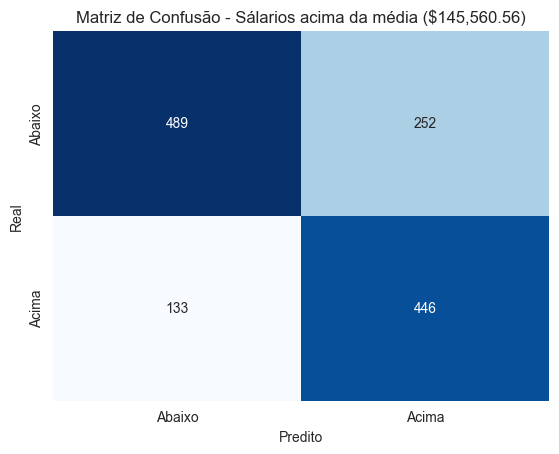

In [21]:
cm = confusion_matrix(y_salary_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Abaixo", "Acima"],
    yticklabels=["Abaixo", "Acima"],
)
plt.title(f"Matriz de Confusão - Sálarios acima da média (${mean_salary:,.2f})")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

#### Analisando os coeficientes do modelo

In [22]:
coef_table = pd.DataFrame(
    {
        "Variável": X_salary_class.columns,
        "Coeficiente_Log": model.coef_[0],
        "Impacto_no_Risco (Odds Ratio)": np.exp(model.coef_[0]),
    }
).sort_values(by="Coeficiente_Log", ascending=False)

display(
    set_styled_caption(
        coef_table.head(20).style.hide(axis="index"),
        "Top 20 variáveis que mais aumentam a chance de salário acima da média:",
    )
)


display(
    set_styled_caption(
        coef_table.tail(10)
        .sort_values(by="Coeficiente_Log", ascending=True)
        .style.hide(axis="index"),
        "Top 10 variáveis que mais reduzem a chance de salário acima da média:",
    )
)

Variável,Coeficiente_Log,Impacto_no_Risco (Odds Ratio)
job_title_Machine Learning Engineer,0.331080,1.392471
employee_residence_United States,0.324610,1.383492
company_location_Australia,0.304357,1.355752
company_location_United States,0.285080,1.329869
experience_level_Senior-level,0.273380,1.314400
job_title_Principal Data Scientist,0.253924,1.289074
company_location_Poland,0.234998,1.264907
employee_residence_Puerto Rico,0.221396,1.247818
experience_level_Executive-level,0.219093,1.244947
company_location_Japan,0.205665,1.228341


Variável,Coeficiente_Log,Impacto_no_Risco (Odds Ratio)
company_location_Portugal,-0.490879,0.612088
job_title_Data Analyst,-0.443883,0.641540
employee_residence_Poland,-0.435528,0.646923
company_location_Brazil,-0.376555,0.686221
experience_level_Entry-level,-0.344639,0.708476
job_title_Machine Learning Research Engineer,-0.329290,0.719434
job_title_Data Developer,-0.278225,0.757127
employee_residence_Turkey,-0.249749,0.778996
employee_residence_Pakistan,-0.241228,0.785662
employee_residence_Australia,-0.239302,0.787177


#### Curva ROC e AUC

**O valor do AUC (Area Under the Curve) é:** 0.7795

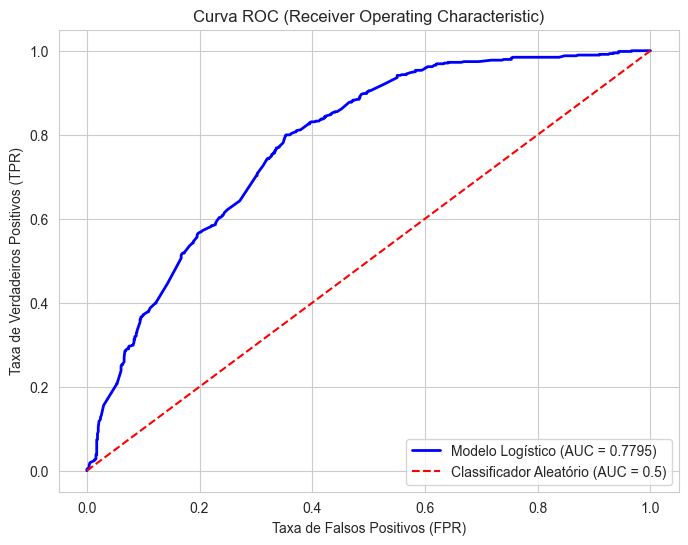

In [23]:
y_probs = model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_salary_test, y_probs)
display(Markdown(f"**O valor do AUC (Area Under the Curve) é:** {auc:.4f}"))

fpr, tpr, thresholds = roc_curve(y_salary_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr, tpr, color="blue", linewidth=2, label=f"Modelo Logístico (AUC = {auc:.4f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    color="red",
    linestyle="--",
    label="Classificador Aleatório (AUC = 0.5)",
)
plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.title("Curva ROC (Receiver Operating Characteristic)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### **Perguntas Executivas**

#### **Q8:** No modelo logístico, quais variáveis aumentam significativamente as chances de um profissional ter **salary acima da média**? Interprete os resultados do **odds ratio**.

##### **Resposta**:

1. O que mais aumenta a chance de ganhar acima da média?
* **Localização:** Morar ou trabalhar para empresas nos **Estados Unidos** e **Austrália**.
* **Cargo:** Ser **Engenheiro de Machine Learning**.
* **Experiência:** Ser de nível **Sênior** ou **Executivo**.

2. Interpretação dos resultados do **odds ratio** (O quanto sua chance aumenta, em porcentagem):  
* **Odds Ratio de 1.39** (Engenheiro de ML) significa **39% mais chance** de ganhar acima da média.
* **Odds Ratio de 1.38** (Morar nos EUA) significa **38% mais chance**.
* **Odds Ratio de 1.31** (Nível Sênior) significa **31% mais chance**.

#### **Q9:** A **curva ROC** e o valor de **AUC** indicam que o modelo logístico tem **boa capacidade preditiva**? O modelo apresenta indícios de **overfitting ou generalização adequada**?

##### **Resposta**:

**Sim**, o modelo apresenta uma boa capacidade preditiva de acordo com a curva ROC e o valor de AUC (0.7795).

* **Capacidade Preditiva (Boa):** O **AUC de 0.78** (78%) é considerado um resultado **bom e satisfatório** para esse tipo de modelo. Isso significa que o modelo tem uma probabilidade de 78% de distinguir corretamente entre um salário "Acima" e um "Abaixo" da média. Ele é significativamente superior a um palpite aleatório (linha pontilhada vermelha, 50%).
* **Overfitting vs. Generalização (Adequada):** O modelo apresenta **generalização adequada**.
    * Não há indícios de *overfitting* (quando o modelo "decora" os dados), pois a curva é suave e o valor não está suspeitosamente próximo de 1.0 (perfeição).
    * Ele capturou bem o padrão geral dos dados sem se perder em ruídos, sendo seguro para aplicar em novos dados.

#### **Q10:** Se você fosse consultor de RH, quais **conclusões práticas e recomendações estratégicas** apresentaria à diretoria com base nos **resultados combinados dos modelos linear e logístico**?

##### **Resposta**:

Com base nos resultados combinados dos modelos:

* **Fatores-Chave Identificados:** O modelo logístico (com boa performance, AUC de 0.78) confirma que os três principais fatores que aumentam a chance de um salário ser **acima da média** são:
    1.  **Cargo** (ex: "Machine Learning Engineer" tem 39% mais chance).
    2.  **Localização** (ex: "Residir nos EUA" tem 38% mais chance).
    3.  **Experiência** (ex: "Nível Sênior" tem 31% mais chance).
* **Modelo Preditivo (Inadequado):** O modelo linear é **impreciso** para prever valores de salário exatos (R² de 31%). Ele erra as previsões em média em **$44.091**, sendo inadequado para definir salários individuais.

**Recomendações Estratégicas:**

* **Revisão de Faixas Salariais:** Devemos focar os esforços de retenção e atração nos cargos de maior impacto (Engenharia de ML, Cientistas de Dados Sênior/Executivo) e garantir que nossas faixas nos EUA sejam referência de mercado.
* **Padronização de Cargos:** A principal causa da imprecisão do modelo linear é a falta de padronização (132 cargos diferentes). O RH deve **agrupar cargos** em "famílias" (ex: Análise de Dados, Engenharia de Dados, Ciência de Dados) para permitir benchmarks e modelos de orçamento mais precisos no futuro.

PS: A análise da distribuição dos dados revela que o dataset **não é nem um pouco balanceado** e está fortemente concentrado em perfis específicos o que influencia bastante o resultado dos modelos:

* **Nível de Experiência:** A grande maioria dos registros é de nível **Sênior (62,21%)**.
* **Porte da Empresa:** Quase 9 em cada 10 registros são de empresas de porte **Médio (88,80%)**.
* **Tipo de Contrato:** O dataset é quase inteiramente composto por vagas **Full-time (99,29%)**.
* **Período:** A maioria expressiva dos dados foi coletada em **2023 (70,09%)**.
* **Localização:** A maioria dos dados está concentrada em poucos países (ex: Majoritariamente EUA, Reino Unido e Canada).